# KDE Explained
Kernel Density Estimation (KDE) is a non-parametric method used to estimate the unknown probability density function (PDF) of a continuous random variable from a finite set of data. It provides a smooth, continuous curve as an alternative to the blocky appearance of a histogram. 
The core idea behind KDE is that each data point suggests a high probability of an observation occurring nearby. 

Intuition:
1) Place a kernal(smooth little bump) on each data point
2) add all the bumps together
3) Normalize so total area sums to 1
We turn a histogram into a smooth continuos graph

# Key Components:
Kernel Function: This is the "building block" used to spread the influence of each data point. Common kernels include Gaussian (normal), uniform, and triangular. The choice of kernel generally has a minor impact on the final result compared to the bandwidth.

Common kernels:

Gaussian (by far the most popular)

Uniform

Epanechnikov

Triangular

Bandwidth (h): Also known as the smoothing parameter or window width, the bandwidth is the most critical factor.
A small bandwidth results in a narrow, spiky estimate that may overfit the data and appear noisy.
A large bandwidth results in a wide, smooth estimate that may oversmooth the data and hide important features like multiple peaks.

Bandwidth controls smoothness.

h:Too small 
Very wiggly,Overfits noise and looks like a bunch of spikes

h:too large 
Oversmoothed,Misses structure,Looks like one big blob

Just right,Captures shape,Smooth but informative

This is the bias–variance tradeoff in disguise.

# Relationship between KDE and Euler Characteristic
To compute the Euler Characteristic from point clouds we need to turn discrete points into a continuous structure. So we want to apply one of the kernals onto our point cloud to estimate a smooth density function over the domain.

In [27]:
def gaussian_kernel(u):
    # Standard normal kernel (already normalized)
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)


def epanechnikov_kernel(u):
    # Compact support kernel
    out = np.zeros_like(u)
    mask = np.abs(u) <= 1
    out[mask] = 0.75 * (1 - u[mask]**2)
    return out


def triangular_kernel(u):
    # Compact support kernel
    out = np.zeros_like(u)
    mask = np.abs(u) <= 1
    out[mask] = 1 - np.abs(u[mask])
    return out

In [31]:
import numpy as np
import matplotlib.pyplot as plt
def kde_1d(x: np.ndarray, grid: np.ndarray, h: float, kernel: str = "gaussian") -> np.ndarray:
    # 1D KDE with selectable kernel

    x = np.asarray(x, dtype=float).reshape(-1)
    grid = np.asarray(grid, dtype=float).reshape(-1)

    if h <= 0:
        raise ValueError("Bandwidth h must be > 0.")

    n = x.size

    # Standardized differences (THIS is the key generalization)
    u = (grid[:, None] - x[None, :]) / h   # shape (m, n)

    # Select kernel
    if kernel == "gaussian":
        K = gaussian_kernel(u)
    elif kernel == "epanechnikov":
        K = epanechnikov_kernel(u)
    elif kernel == "triangular":
        K = triangular_kernel(u)
    else:
        raise ValueError("kernel must be 'gaussian', 'epanechnikov', or 'triangular'")

    # KDE formula: (1 / (n h)) * sum K
    density = np.sum(K, axis=1) / (n * h)

    return density

def plot_kde(x: np.ndarray, h: float, kernel: str = "gaussian", grid_points: int = 400):
    # Plot histogram + KDE curve + rug plot

    x = np.asarray(x, dtype=float).reshape(-1)

    pad = 0.1 * (x.max() - x.min())
    grid = np.linspace(x.min() - pad, x.max() + pad, grid_points)

    dens = kde_1d(x, grid, h, kernel=kernel)

    plt.figure()
    plt.hist(x, bins=30, density=True, alpha=0.3)
    plt.plot(grid, dens, linewidth=2)

    ymin, ymax = plt.ylim()
    rug_y = ymin + 0.02 * (ymax - ymin)
    plt.plot(x, np.full_like(x, rug_y), "|", markersize=10)

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"{kernel.capitalize()} KDE (h={h})")
    plt.show()

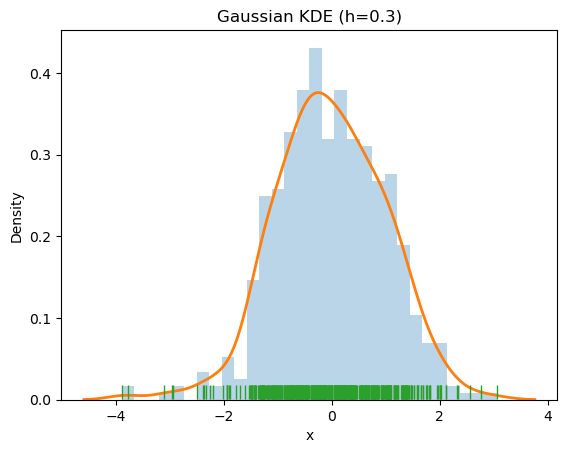

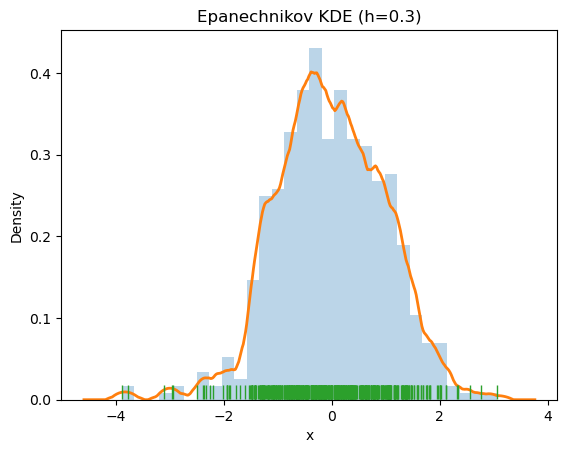

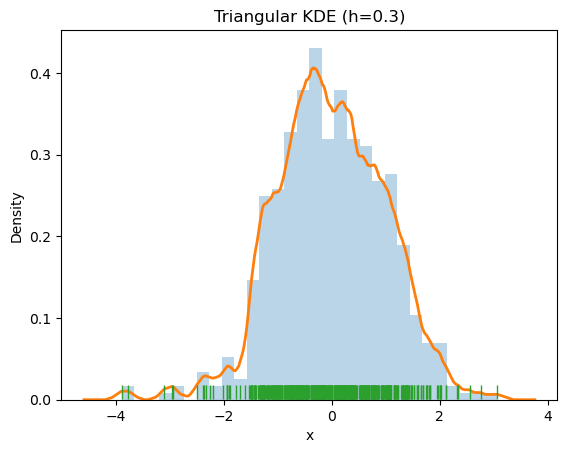

In [33]:
rng = np.random.default_rng(0)
x = rng.normal(0, 1, size=500)

plot_kde(x, h=0.3, kernel="gaussian")
plot_kde(x, h=0.3, kernel="epanechnikov")
plot_kde(x, h=0.3, kernel="triangular")

In [39]:
def plot_kde_single_bandwidth(x, h, kernel="gaussian", grid_points=400):
    x = np.asarray(x, dtype=float).reshape(-1)

    pad = 0.1 * (x.max() - x.min())
    grid = np.linspace(x.min() - pad, x.max() + pad, grid_points)

    dens = kde_1d(x, grid, h, kernel=kernel)

    plt.figure()
    plt.hist(x, bins=30, density=True, alpha=0.3)
    plt.plot(grid, dens, linewidth=2)

    # Rug plot
    ymin, ymax = plt.ylim()
    rug_y = ymin + 0.02 * (ymax - ymin)
    plt.plot(x, np.full_like(x, rug_y), "|", markersize=10)

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"{kernel.capitalize()} KDE (h = {h})")
    plt.show()

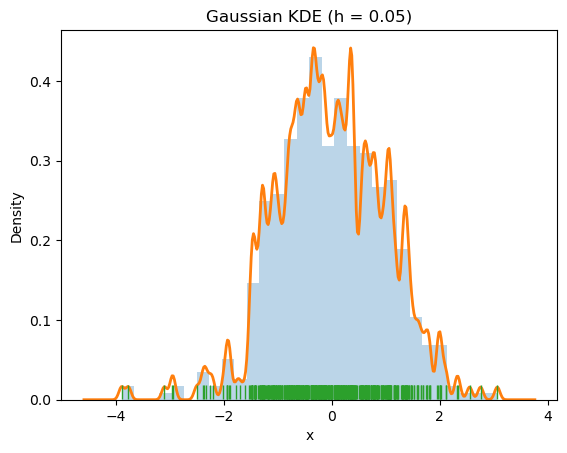

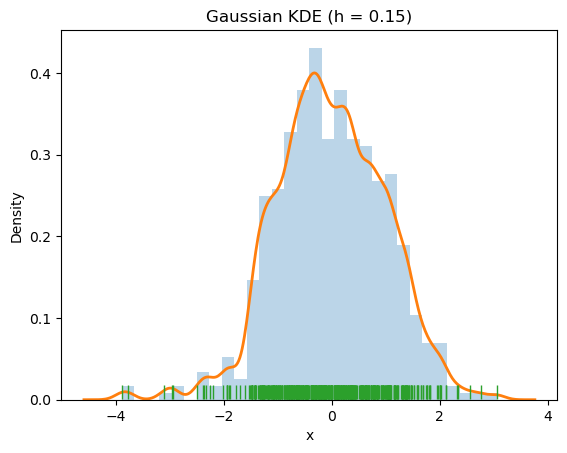

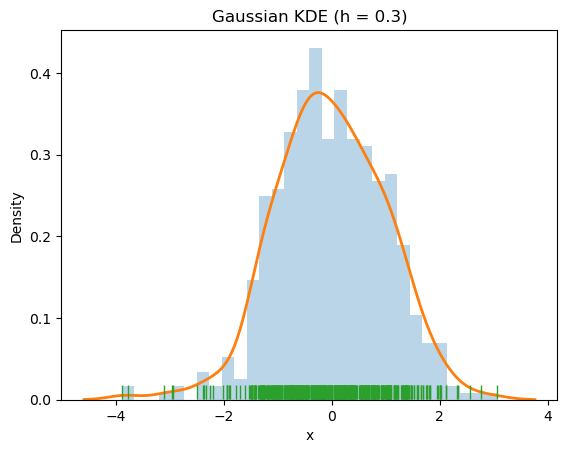

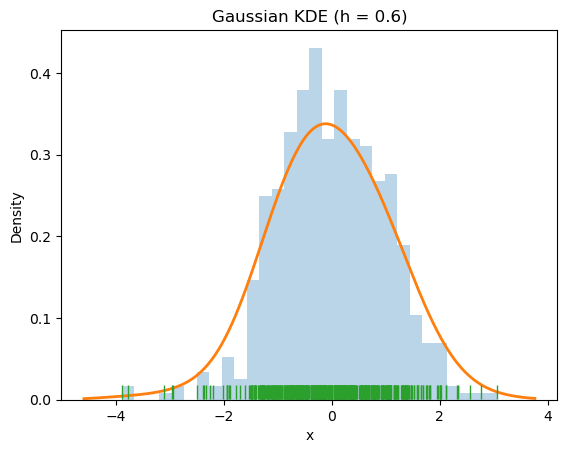

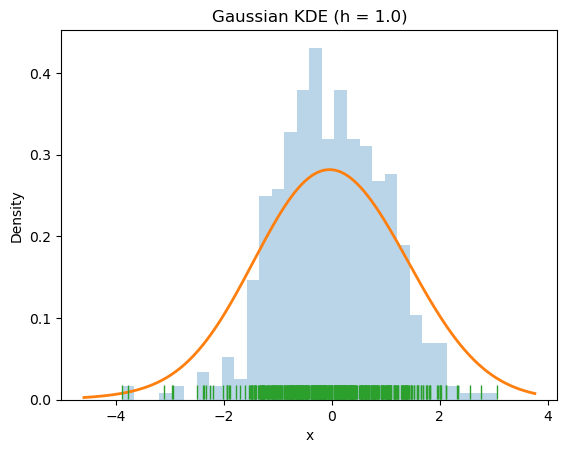

In [45]:
rng = np.random.default_rng(0)
x = rng.normal(0, 1, size=500)

bandwidths = [0.05, 0.15, 0.3, 0.6, 1.0]

for h in bandwidths:
    plot_kde_single_bandwidth(x, h, kernel="gaussian")


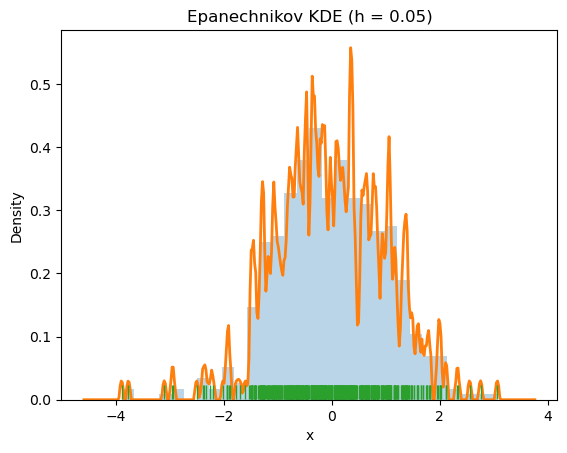

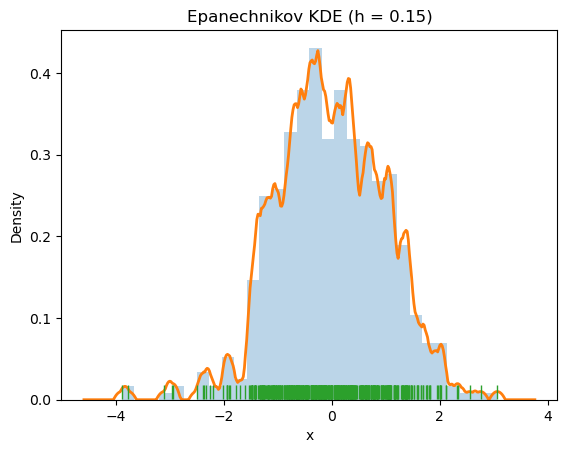

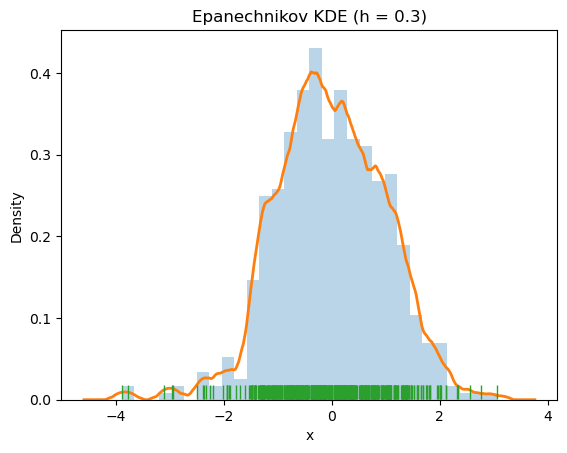

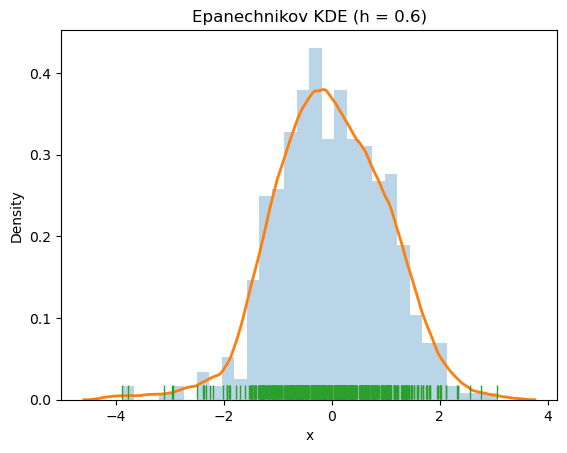

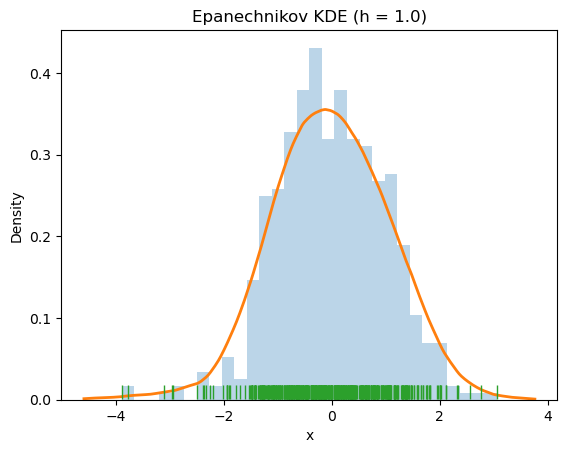

In [47]:
rng = np.random.default_rng(0)
x = rng.normal(0, 1, size=500)

bandwidths = [0.05, 0.15, 0.3, 0.6, 1.0]

for h in bandwidths:
    plot_kde_single_bandwidth(x, h, kernel="epanechnikov")
    

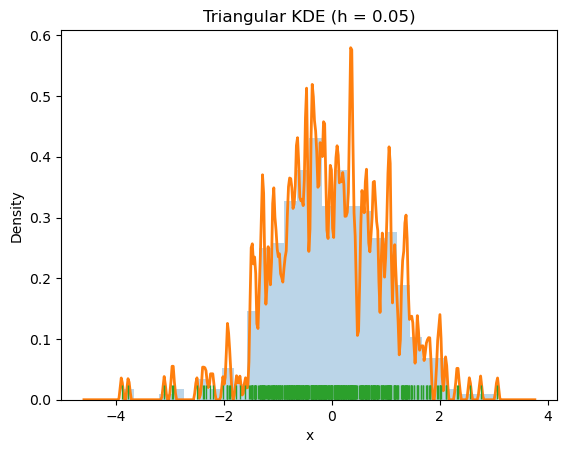

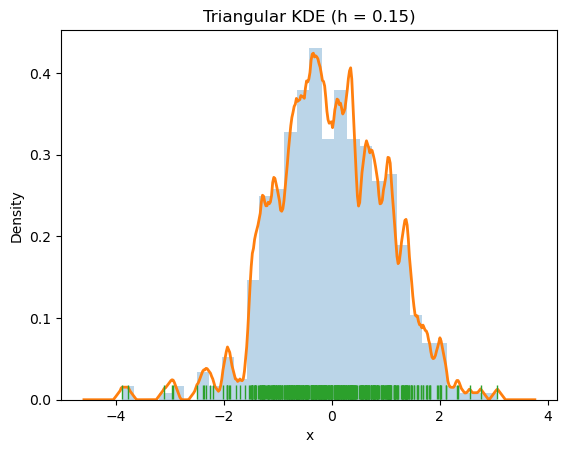

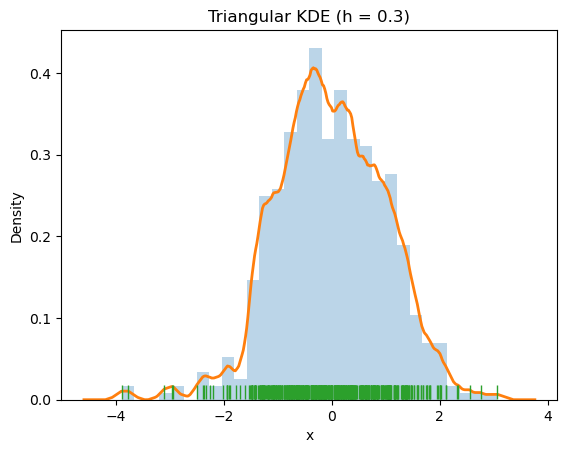

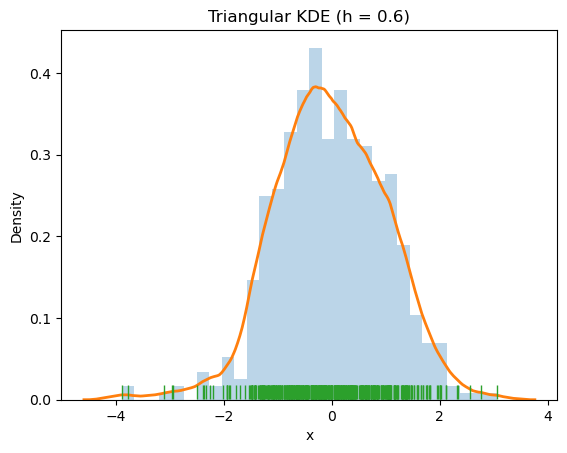

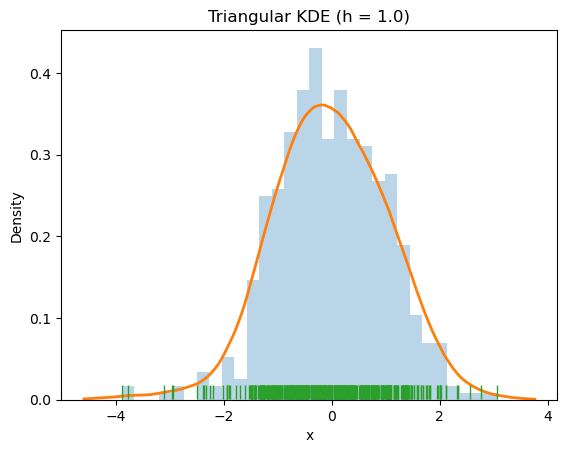

In [49]:
rng = np.random.default_rng(0)
x = rng.normal(0, 1, size=500)

bandwidths = [0.05, 0.15, 0.3, 0.6, 1.0]
for h in bandwidths:
    plot_kde_single_bandwidth(x, h, kernel="triangular")


# 2D KDE
Instead of each data point being a bump on a line(1d), adding a bump creates a curve

In 2D each one of our data points is a hill on a plane, adding a bump creates a density surface

Instead of estimating a curve, you estimate a landscape.

High regions = lots of nearby points

Low regions = sparse areas

# Formula(insert later):
Same idea but distance is now euclidian 
Kernal is now radially symmetric

In 2D:

Undersmoothing = noisy islands

Oversmoothing = one giant blob

In [53]:
#Coding 2D KDE
#Gaussian kernal
def gaussian_kde_2d(X, grid_x, grid_y, h):
    """
    2D Gaussian KDE with isotropic bandwidth h.

    X      : (n, 2) data points
    grid_x : (m,) x-coordinates of evaluation grid
    grid_y : (k,) y-coordinates of evaluation grid
    h      : bandwidth

    Returns:
    density : (m, k) array of KDE values
    """

    X = np.asarray(X, dtype=float)
    grid_x = np.asarray(grid_x, dtype=float)
    grid_y = np.asarray(grid_y, dtype=float)

    if h <= 0:
        raise ValueError("Bandwidth h must be > 0.")

    n = X.shape[0]

    # Create meshgrid
    gx, gy = np.meshgrid(grid_x, grid_y, indexing="ij")

    # Initialize density
    density = np.zeros_like(gx)

    # Normalization constant
    const = 1.0 / (n * 2 * np.pi * h**2)

    # Sum Gaussian bumps
    for i in range(n):
        dx = gx - X[i, 0]
        dy = gy - X[i, 1]
        density += np.exp(-(dx**2 + dy**2) / (2 * h**2))

    density *= const
    return density

In [55]:
def plot_kde_2d(X, h, grid_points=100):
    X = np.asarray(X, dtype=float)

    pad_x = 0.1 * (X[:,0].max() - X[:,0].min())
    pad_y = 0.1 * (X[:,1].max() - X[:,1].min())

    grid_x = np.linspace(X[:,0].min() - pad_x, X[:,0].max() + pad_x, grid_points)
    grid_y = np.linspace(X[:,1].min() - pad_y, X[:,1].max() + pad_y, grid_points)

    density = gaussian_kde_2d(X, grid_x, grid_y, h)

    plt.figure()
    plt.contourf(grid_x, grid_y, density.T, levels=30)
    plt.scatter(X[:,0], X[:,1], s=10, c="black", alpha=0.5)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"2D Gaussian KDE (h = {h})")
    plt.show()

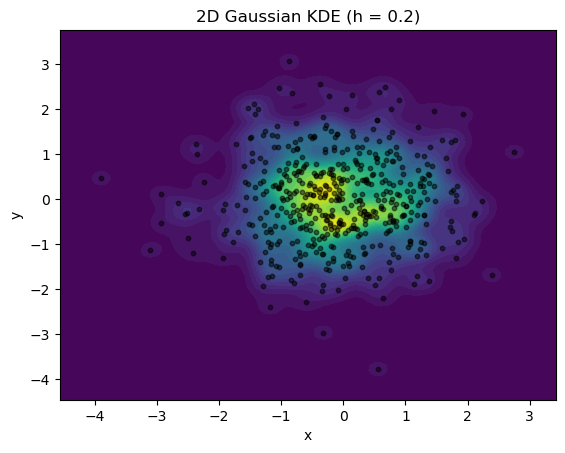

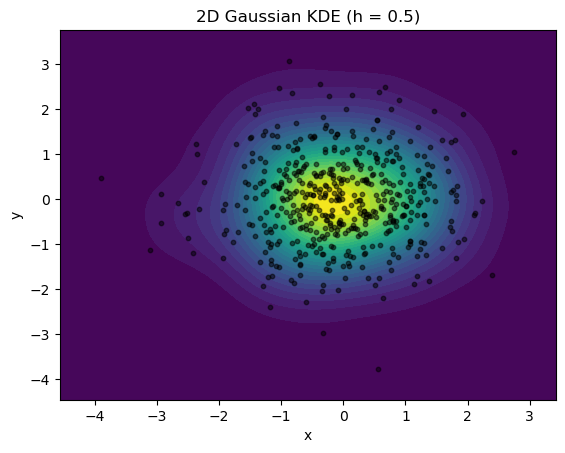

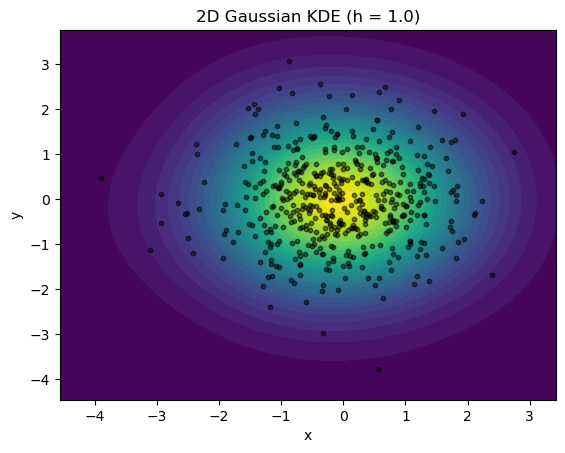

In [57]:
rng = np.random.default_rng(0)
X = rng.normal(0, 1, size=(500, 2))

plot_kde_2d(X, h=0.2)
plot_kde_2d(X, h=0.5)
plot_kde_2d(X, h=1.0)

In [63]:
def epanechnikov_kde_2d(X, grid_x, grid_y, h):
    X = np.asarray(X, dtype=float)
    grid_x = np.asarray(grid_x, dtype=float)
    grid_y = np.asarray(grid_y, dtype=float)

    if h <= 0:
        raise ValueError("Bandwidth h must be > 0.")

    n = X.shape[0]
    gx, gy = np.meshgrid(grid_x, grid_y, indexing="ij")
    density = np.zeros_like(gx)

    # Constant: 2 / (pi * h^2 * n)
    const = 2.0 / (np.pi * h**2 * n)

    for i in range(n):
        dx = gx - X[i, 0]
        dy = gy - X[i, 1]
        u2 = (dx**2 + dy**2) / h**2
        mask = u2 <= 1
        density[mask] += 1 - u2[mask]

    density *= const
    return density

In [65]:
def triangular_kde_2d(X, grid_x, grid_y, h):
    X = np.asarray(X, dtype=float)
    grid_x = np.asarray(grid_x, dtype=float)
    grid_y = np.asarray(grid_y, dtype=float)

    if h <= 0:
        raise ValueError("Bandwidth h must be > 0.")

    n = X.shape[0]
    gx, gy = np.meshgrid(grid_x, grid_y, indexing="ij")
    density = np.zeros_like(gx)

    # Constant: 6 / (pi * h^2 * n)
    const = 6.0 / (np.pi * h**2 * n)

    for i in range(n):
        dx = gx - X[i, 0]
        dy = gy - X[i, 1]
        dist = np.sqrt(dx**2 + dy**2)
        mask = dist <= h
        density[mask] += 1 - dist[mask] / h

    density *= const
    return density

In [67]:
#Helper function to help with plotting
def plot_kde_2d_kernel(X, h, kernel="gaussian", grid_points=100):
    X = np.asarray(X, dtype=float)

    pad_x = 0.1 * (X[:,0].max() - X[:,0].min())
    pad_y = 0.1 * (X[:,1].max() - X[:,1].min())

    grid_x = np.linspace(X[:,0].min() - pad_x, X[:,0].max() + pad_x, grid_points)
    grid_y = np.linspace(X[:,1].min() - pad_y, X[:,1].max() + pad_y, grid_points)

    if kernel == "gaussian":
        density = gaussian_kde_2d(X, grid_x, grid_y, h)
    elif kernel == "epanechnikov":
        density = epanechnikov_kde_2d(X, grid_x, grid_y, h)
    elif kernel == "triangular":
        density = triangular_kde_2d(X, grid_x, grid_y, h)
    else:
        raise ValueError("Unknown kernel")

    plt.figure()
    plt.contourf(grid_x, grid_y, density.T, levels=30)
    plt.scatter(X[:,0], X[:,1], s=10, c="black", alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"2D {kernel.capitalize()} KDE (h = {h})")
    plt.show()

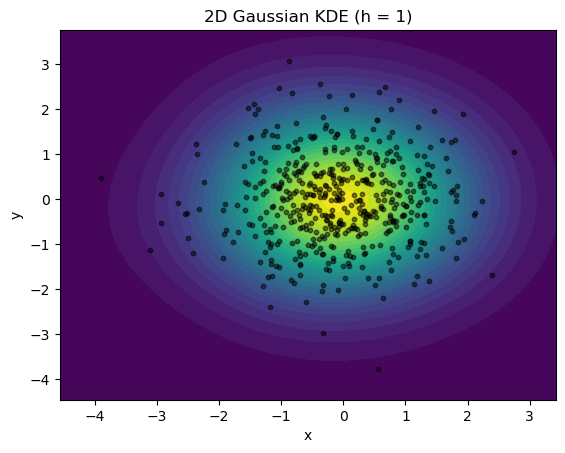

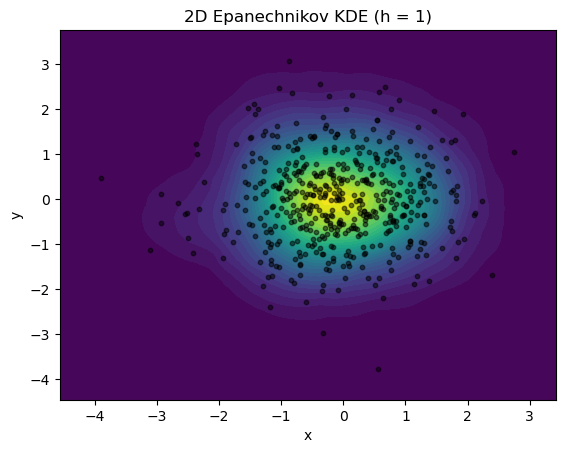

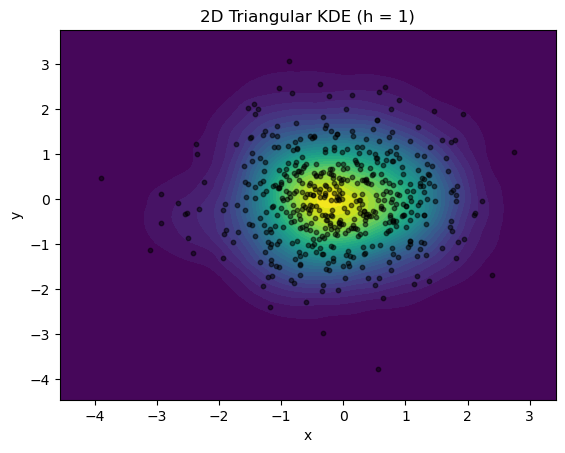

In [73]:
#Testing 3 different types of distribution in 2D(Gaussian,Epanechnikov,Triangular)
rng = np.random.default_rng(0)
X = rng.normal(0, 1, size=(500, 2))

# Gaussian
plot_kde_2d_kernel(X, h=1, kernel="gaussian")
# Epanechnikov
plot_kde_2d_kernel(X, h=1, kernel="epanechnikov")
# Triangular
plot_kde_2d_kernel(X, h=1, kernel="triangular")